# 加入類別權重訓練 — 單階段 9 類分類
每個 Cell 對應一個獨立步驟，可分開執行：
- **Cell 1**：環境設定（只需執行一次）
- **Cell 2**：實驗設定（換參數只改這裡，改完重跑 Cell 4+）
- **Cell 3**：載入資料（只需執行一次，換設定不需重跑）
- **Cell 4**：準備資料集
- **Cell 5**：類別不平衡參數
- **Cell 6**：模型與優化器
- **Cell 7**：訓練
- **Cell 8**：測試集評估
- **Cell 9**：最終圖表
- **Cell 10**：儲存結果（選用）

In [1]:
import sys
sys.path.insert(0, '..')
# Cell 1 — 環境設定（只需執行一次）
%matplotlib inline
import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tabulate import tabulate

from engine.trainer import print_metrics, print_per_class_f1, run_one_epoch, train_model
from engine.visualize import plot_cm, plot_history
from models.builder import build_model
from data.dataset import WaferDataset, extract_labeled_patterned_data, load_raw_data, make_dataloaders, split_df, undersample_none
from constant import LABEL_MAP
from utils import make_output_dir, save_results

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"使用裝置：{device}")

/Users/fe-edward/personal/wafer-map-detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


使用裝置：mps


In [2]:
# Cell 2 — 實驗設定（換參數只改這裡，改完重跑 Cell 4+）
EXPERIMENT_NAME    = "class_weights"
IMAGE_SIZE         = (32,32)
BATCH_SIZE         = 32
EPOCHS             = 24
LR                 = 1e-3
RANDOM_SEED        = 42

NONE_CAP = 10000

In [3]:
# Cell 3 — 載入資料（只需執行一次，換設定不用重跑）
print("下載/讀取 WM-811K 資料集...")
df = load_raw_data()
df_with_label, _, _ = extract_labeled_patterned_data(df)
print(f"有標籤資料：{len(df_with_label)} 筆")

下載/讀取 WM-811K 資料集...


In [4]:
# Cell 4 — 準備資料集
train_df, val_df, test_df = split_df(
    df_with_label, stratify_col="failureType", random_seed=RANDOM_SEED,
)

# 將 None 類別數量降至 10000
train_df = undersample_none(train_df, none_cap=NONE_CAP, random_seed=RANDOM_SEED)

num_classes = len(LABEL_MAP)
datasets = {
    "train": WaferDataset(train_df, image_size=IMAGE_SIZE),
    "val":   WaferDataset(val_df, image_size=IMAGE_SIZE),
    "test":  WaferDataset(test_df, image_size=IMAGE_SIZE),
}
dataloaders = make_dataloaders(datasets, BATCH_SIZE)

In [5]:
# Cell 5 - 類別不平衡
from sklearn.utils.class_weight import compute_class_weight

unique, counts = np.unique(datasets["train"].targets, return_counts=True)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique,
    y=datasets["train"].targets
)
print("old class_weights:", class_weights)

class_weights = np.clip(class_weights, 0.5, 5.0)
class_weights = class_weights / class_weights.mean()
print("new class_weights:", class_weights)


class_weights = torch.tensor(class_weights, dtype=torch.float32)
class_weights = class_weights.to(device)

old class_weights: [ 1.02990316  7.95858326  0.85239232  0.45689033  1.23096974 29.76816239
  5.10872754  3.70765136  0.30958889]
new class_weights: [0.4061681  1.97187522 0.33616226 0.19718752 0.48546375 1.97187522
 1.97187522 1.46220517 0.19718752]


In [6]:
# Cell 6 — 模型與優化器
model = build_model(num_classes, device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = AdamW(params, lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)
print(f"模型與資料集準備完成，類別數：{num_classes}")

模型與資料集準備完成，類別數：9


In [7]:
# Cell 7 — 訓練
best_state, best_f1, best_cm, best_f1_per_class, history = train_model(
    model, device, criterion, optimizer, scheduler, dataloaders,
    num_classes=num_classes,
    epochs=EPOCHS,
    lr=LR,
)
print(f"\n訓練完成，最佳驗證 F1：{best_f1:.4f}")

===== Epoch 1/24 =====
+---------+---------+--------+--------+-------------+----------+
| Split   |    Loss |     F1 |    Acc |   Precision |   Recall |
+=========+=========+========+========+=============+==========+
| Train   |  2.0854 | 0.2528 | 0.3744 |      0.2577 |   0.3217 |
+---------+---------+--------+--------+-------------+----------+
| Val     | 25.7056 | 0.2775 | 0.6605 |      0.2387 |   0.4419 |
+---------+---------+--------+--------+-------------+----------+
+----------+---------+------------+-------------+-------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |   Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+=======+=============+==========+===========+========+
|   0.2435 |  0.3313 |     0.1128 |       0.517 | 0.151 |      0.1231 |   0.1722 |    0.0498 |  0.797 |
+----------+---------+------------+-------------+-------+-------------+----------+-----------+--------+

=

In [8]:
# Cell 8 — 測試集評估
model.load_state_dict(best_state)
test_m = run_one_epoch(model, device, dataloaders["test"], criterion, num_classes=num_classes)
print("\n--- Test Results ---")
print(tabulate(
    [[f"{test_m['loss']:.4f}", f"{test_m['f1']:.4f}",
      f"{test_m['acc']:.4f}", f"{test_m['precision']:.4f}", f"{test_m['recall']:.4f}"]],
    headers=["Loss", "F1", "Acc", "Precision", "Recall"],
    tablefmt="grid",
))
print("\n--- Per-Class F1 ---")
print_per_class_f1(test_m["per_class_f1"])


--- Test Results ---
+--------+--------+--------+-------------+----------+
|   Loss |     F1 |    Acc |   Precision |   Recall |
+========+========+========+=============+==========+
| 0.4371 | 0.7201 | 0.9008 |      0.6591 |   0.8356 |
+--------+--------+--------+-------------+----------+

--- Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.7838 |  0.8249 |     0.5436 |      0.9353 | 0.5158 |      0.9362 |   0.7687 |    0.2239 |  0.949 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


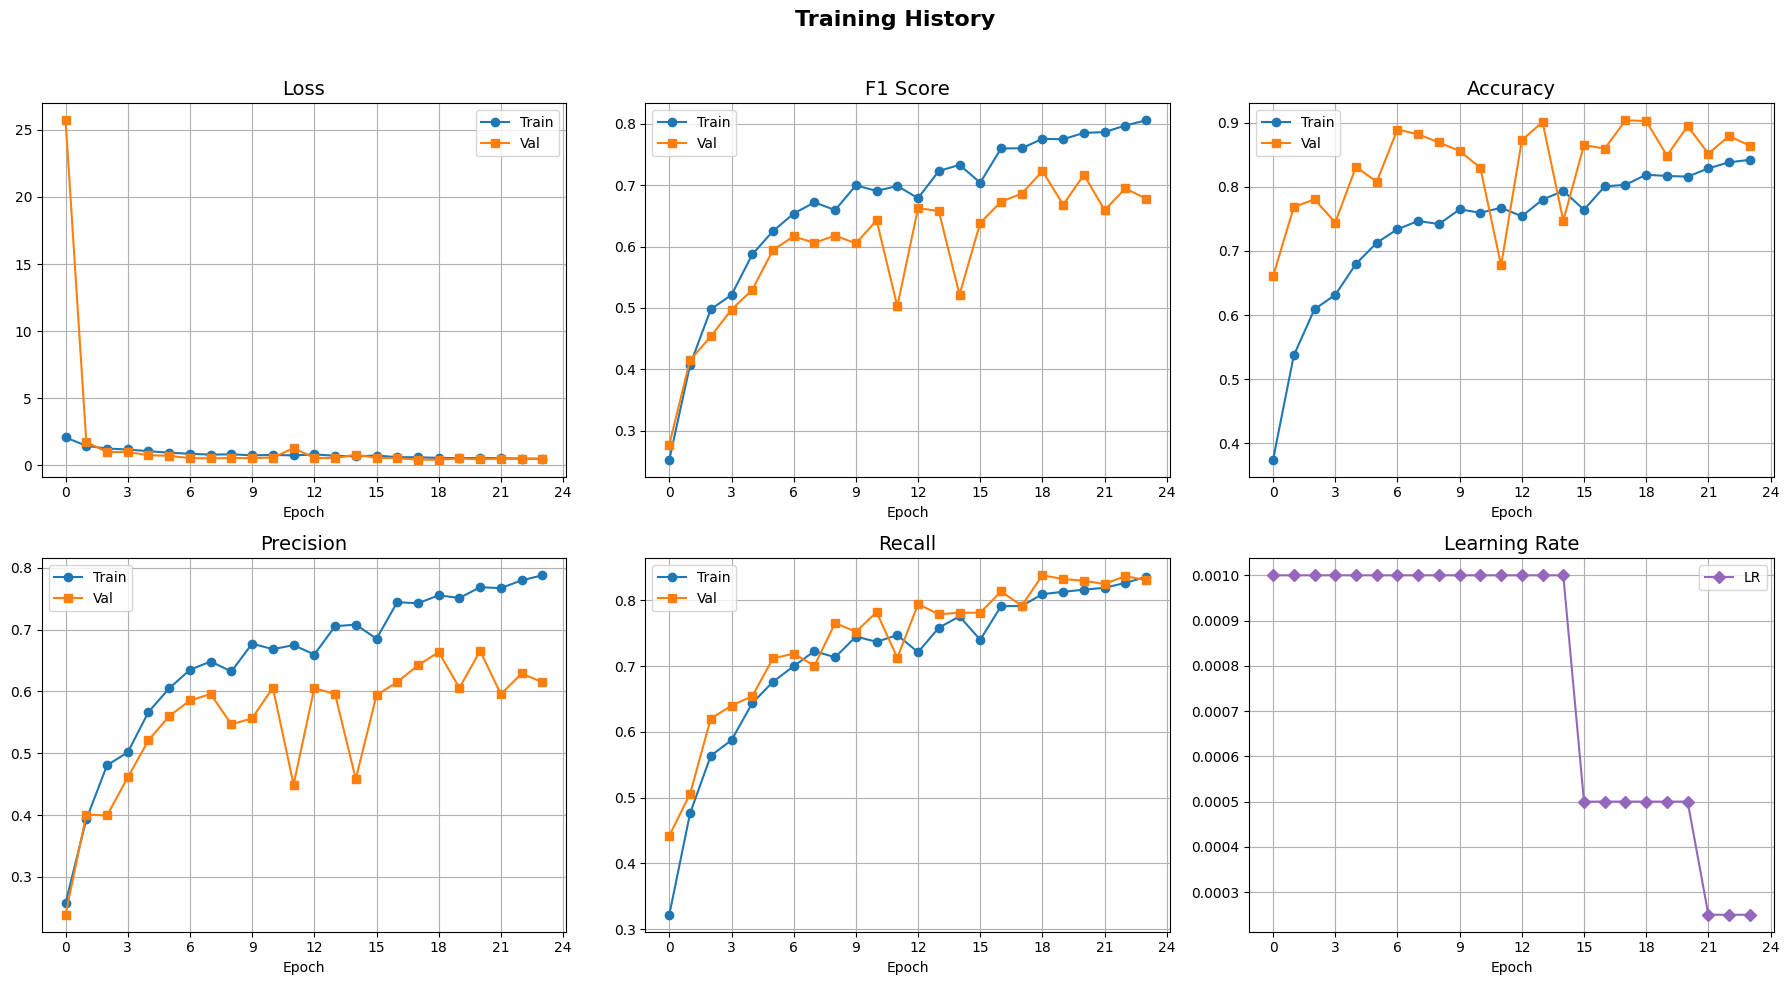

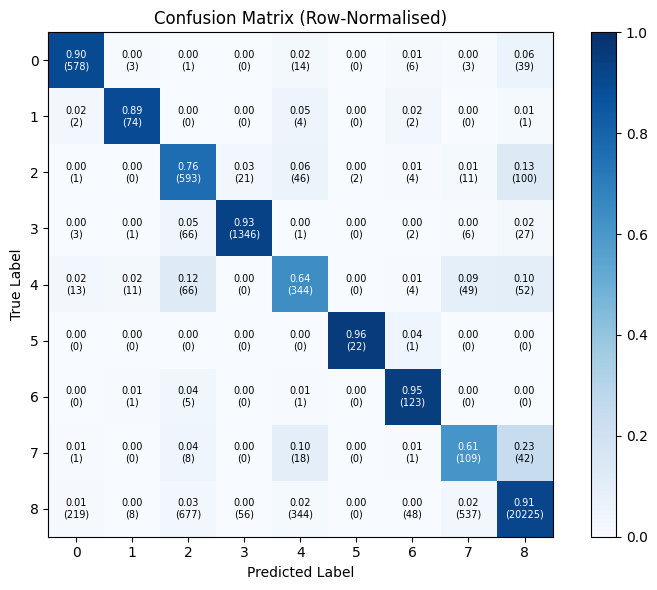


--- Best Val Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.7912 |  0.8177 |     0.5406 |      0.9363 | 0.5248 |      0.9362 |   0.7664 |    0.2438 | 0.9495 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


In [9]:
# Cell 9 — 最終圖表
plot_history(history, show=True)
plot_cm(best_cm, num_classes, show=True)
print("\n--- Best Val Per-Class F1 ---")
print_per_class_f1(best_f1_per_class)

In [10]:
# Cell 10 — 儲存結果（選用）
out_dir = make_output_dir(EXPERIMENT_NAME)
save_results(
    out_dir, model, best_state, best_f1, best_cm, best_f1_per_class,
    history, num_classes, LABEL_MAP, IMAGE_SIZE,
)
print(f"結果已儲存至：{out_dir}")

Results saved to outputs/class_weights_20260708_175533
結果已儲存至：outputs/class_weights_20260708_175533


**class_weights_20260525_194832** 訓練結果筆記

原本想優化 baseline 的訓練，使用class weights 的策略，訓練結果竟然更差。

- baseline best F1: 0.82, 
- baseline Scratch class f1: 0.54, 
- with class weights best F1: 0.72。
- with class weights Scratch class F1: 0.2

跟 AI 討論了可能的原因，結論如下：

1. Scratch 特徵模糊，跟 none 很像
2. 加了 high weight 後，每次 Scratch 分錯的懲罰很大
3. 但模型沒有足夠的樣本學會 Scratch 的真正特徵
4. 模型面對 Scratch 時，因為沒有確信的判斷依據，不敢預測 Scratch（因為預測錯 Scratch 的代價太高）
5. 反而傾向預測更安全的大類別（none、Edge-Ring）來規避風險

**下一步應該採取的策略**：
- 不用 class weights
- 難分辨的類別資料增強
- 提升資料輸入解析度
- 二階段辨識，第一階段要高Recall率，閾值調低，>0.3就丟到non-None

In [ ]:
i = LABEL_MAP['Scratch']
cm = best_cm
recall    = cm[i, i] / cm[i, :].sum()
precision = cm[i, i] / cm[:, i].sum()
row = cm[i, :]        # 真 Scratch 被分去哪裡了（看 recall 有沒有漏、漏去哪）
col = cm[:, i]        # 被判成 Scratch 的都來自哪些真類（看 precision 被誰灌爆）
print('R', recall, 'P', precision)
print('true-Scratch 流向:', dict(zip(LABEL_MAP, row)))
print('pred-Scratch 來源:', dict(zip(LABEL_MAP, col)))

R 0.6089385474860335 P 0.15244755244755245
true-Scratch 流向: {'Center': np.int64(1), 'Donut': np.int64(0), 'Edge-Loc': np.int64(8), 'Edge-Ring': np.int64(0), 'Loc': np.int64(18), 'Near-full': np.int64(0), 'Random': np.int64(1), 'Scratch': np.int64(109), 'none': np.int64(42)}
pred-Scratch 來源: {'Center': np.int64(3), 'Donut': np.int64(0), 'Edge-Loc': np.int64(11), 'Edge-Ring': np.int64(6), 'Loc': np.int64(49), 'Near-full': np.int64(0), 'Random': np.int64(0), 'Scratch': np.int64(109), 'none': np.int64(537)}


: 